# Loading and Running  LoRA Fine-Tuned Model

## 1. Basic Inference Script

In [4]:
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

# Paths
base_model_dir = "models/Qwen2.5-3B-Instruct"
adapter_dir = "outputs/lora_qwen25_3b_success/final_adapter"  # your LoRA output

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(adapter_dir)

# Load base model
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_dir,
    dtype=torch.float32,
).to(device).eval()

# Attach LoRA adapter
model = PeftModel.from_pretrained(base_model, adapter_dir)
model.eval()

device: mps


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

RuntimeError: MPS backend out of memory (MPS allocated: 30.19 GB, other allocations: 448.00 KB, max allowed: 30.19 GB). Tried to allocate 86.00 MB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).

## Running Inference

In [7]:
def predict(instruction: str, input_text: str) -> str:
    prompt = f"Instruction: {instruction}\n\nInput:\n{input_text}\n\nOutput:\n"

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,        # greedy for classification
            temperature=1.0,
        )

    # Decode only the newly generated tokens
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True).strip()

result = predict(
    instruction="Predict whether this zeolite synthesis will succeed.",
    input_text="<your synthesis conditions here>"
)
print(result)  # e.g. "success" or "failed"

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


failed


## Batch Inference on Test Split

In [9]:
import json
import pandas as pd
from tqdm.auto import tqdm

test_df = pd.read_json("outputs/lora_qwen25_3b_success/test_split.jsonl", lines=True)

predictions = []
for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Inferencing"):
    pred = predict(row["instruction"], row["input"])
    predictions.append(pred)

test_df["prediction"] = predictions

# Check accuracy
accuracy = (test_df["prediction"] == test_df["output"]).mean()
print(f"Accuracy: {accuracy:.4f}")

Inferencing:   0%|          | 0/3761 [00:00<?, ?it/s]

Accuracy: 0.7219


## Random Forest in the same datasets

In [14]:
# 与 LoRA 一致的 group 切分（70/15/15）
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupShuffleSplit

prompt_file = Path("outputs/prompts/recipe_success.jsonl")
rows = [json.loads(x) for x in prompt_file.read_text(encoding="utf-8").splitlines() if x.strip()]
df = pd.DataFrame(rows)

# 与 scripts/finetune_lora.py 一致
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_valid_idx, test_idx = next(gss1.split(df, groups=df["group_id"]))
train_valid_df = df.iloc[train_valid_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)  # 0.85*0.1765≈0.15
train_idx, valid_idx = next(gss2.split(train_valid_df, groups=train_valid_df["group_id"]))
train_df = train_valid_df.iloc[train_idx].reset_index(drop=True)
valid_df = train_valid_df.iloc[valid_idx].reset_index(drop=True)

print(len(train_df), len(valid_df), len(test_df))
print("group overlap(train,test):", len(set(train_df.group_id) & set(test_df.group_id)))
print("group overlap(train,valid):", len(set(train_df.group_id) & set(valid_df.group_id)))
print("group overlap(valid,test):", len(set(valid_df.group_id) & set(test_df.group_id)))


21489 4914 3761
group overlap(train,test): 0
group overlap(train,valid): 0
group overlap(valid,test): 0


In [15]:
# Cell 2 - 构建 baseline 特征（和原 baseline 一样）
import json
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

routes = pd.read_csv("database/csv_tables/synthesis_routes.csv", low_memory=False)
products = pd.read_csv("database/csv_tables/product_table.csv", low_memory=False)
osda = pd.read_csv("database/csv_tables/osda_table.csv", low_memory=False)

def parse_osda_descriptors(osda_table):
    rows = []
    for _, r in osda_table.iterrows():
        d = {}
        raw = r.get("descriptor_json")
        if isinstance(raw, str) and raw.strip():
            try:
                d.update(json.loads(raw))
            except json.JSONDecodeError:
                pass
        d["mol_weight"] = r.get("mol_weight")
        d["formal_charge"] = r.get("formal_charge")
        d["osda_id"] = r.get("osda_id")
        rows.append(d)
    desc = pd.DataFrame(rows)
    desc = desc.rename(columns={c: f"osda_{c}" for c in desc.columns if c != "osda_id"})
    desc["osda_id"] = pd.to_numeric(desc["osda_id"], errors="coerce").astype("Int64")
    return desc

def choose_largest_volume_osda_id(route_row, osda_meta):
    cands = []
    for col in ("osda1_id", "osda2_id", "osda3_id"):
        v = route_row.get(col)
        if pd.notna(v):
            try: cands.append(int(v))
            except: pass
    if not cands: return None

    best_id, best_v = None, -np.inf
    for oid in cands:
        meta = osda_meta.get(oid)
        if not meta: 
            continue
        vv = meta.get("osda_volume_mean_0")
        vv = float(vv) if vv is not None and pd.notna(vv) else np.nan
        if pd.notna(vv) and vv > best_v:
            best_v, best_id = vv, oid
    if best_id is not None:
        return best_id
    for oid in cands:
        if oid in osda_meta:
            return oid
    return None

osda_desc = parse_osda_descriptors(osda)
prod = products[["route_id", "primary_topology", "failure_label"]].copy()
merged = routes.merge(prod, on="route_id", how="inner")

gel_cols = sorted([c for c in merged.columns if c.endswith("_ratio_to_t")])
process_cols = [c for c in ["cryst_time", "cryst_temp"] if c in merged.columns]

osda_feature_cols = [c for c in osda_desc.columns if c != "osda_id"]
osda_meta = osda_desc.set_index("osda_id")[osda_feature_cols].to_dict(orient="index")
largest_ids = merged.apply(lambda r: choose_largest_volume_osda_id(r, osda_meta), axis=1)

osda_feat = pd.DataFrame(
    [osda_meta.get(int(oid), {}) if pd.notna(oid) and oid is not None else {} for oid in largest_ids],
    index=merged.index
)

X_all = pd.concat([merged[gel_cols + process_cols], osda_feat], axis=1)
for c in X_all.columns:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")

route_to_idx = pd.Series(merged.index.values, index=merged["route_id"]).to_dict()


In [16]:
# Cell 3 - 按 LoRA split 的 route_id 对齐样本，并做二分类标签
def select_xy(split_df):
    rid = pd.to_numeric(split_df["route_id"], errors="coerce").dropna().astype(int).tolist()
    idx = [route_to_idx[r] for r in rid if r in route_to_idx]
    X = X_all.loc[idx].copy()

    # 二分类：success=1, failed=0（来自 recipe_success.jsonl 的 output）
    y_txt = split_df.set_index("route_id").loc[[r for r in rid if r in route_to_idx], "output"].astype(str).str.lower()
    y = y_txt.map(lambda s: 1 if s == "success" else 0).values
    return X, y

X_train, y_train = select_xy(train_df)
X_valid, y_valid = select_xy(valid_df)
X_test, y_test = select_xy(test_df)

print("train/valid/test:", len(y_train), len(y_valid), len(y_test))
print("pos rate:", y_train.mean(), y_valid.mean(), y_test.mean())


train/valid/test: 21489 4914 3761
pos rate: 0.4425054679138164 0.5252340252340252 0.4754054772666844


In [20]:
# Cell 4 - 训练与评估（二分类）
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_valid_imp = imputer.transform(X_valid)
X_test_imp = imputer.transform(X_test)

clf = RandomForestClassifier(random_state=42)  # baseline 默认参数
clf.fit(X_train_imp, y_train)

valid_pred = clf.predict(X_valid_imp)
test_pred = clf.predict(X_test_imp)

print("Valid Acc:", accuracy_score(y_valid, valid_pred))
print("Test  Acc:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred, digits=4, zero_division=0))


Valid Acc: 0.6988196988196989
Test  Acc: 0.7189577240095719
              precision    recall  f1-score   support

           0     0.8403    0.5732    0.6815      1973
           1     0.6513    0.8798    0.7485      1788

    accuracy                         0.7190      3761
   macro avg     0.7458    0.7265    0.7150      3761
weighted avg     0.7505    0.7190    0.7134      3761



对比微调前后的LLM

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

In [2]:
#  读取 jsonl
jsonl_path = "outputs/lora_inference_compare/comparison_records.jsonl"   # 改成你的文件路径

df = pd.read_json(jsonl_path, lines=True)

print("数据量:", len(df))
print("列名:", df.columns.tolist())
display(df.head())

数据量: 3761
列名: ['task', 'route_id', 'paper_id', 'gold', 'base_pred', 'lora_pred', 'changed']


,task,route_id,paper_id,gold,base_pred,lora_pred,changed
0,success,11,59.0,success,failed,success,True
1,success,12,59.0,success,failed,success,True
2,success,13,59.0,success,failed,success,True
3,success,14,59.0,success,failed,success,True
4,success,15,59.0,success,failed,success,True


In [3]:
# Cell 3: 标签清洗
# 防止大小写、空格影响评测

for col in ["gold", "base_pred", "lora_pred"]:
    df[col] = df[col].astype(str).str.strip().str.lower()

print("gold label 分布:")
print(df["gold"].value_counts())
print("\nbase_pred 分布:")
print(df["base_pred"].value_counts())
print("\nlora_pred 分布:")
print(df["lora_pred"].value_counts())

gold label 分布:
gold
failed     1973
success    1788
Name: count, dtype: int64

base_pred 分布:
base_pred
failed     3556
success     205
Name: count, dtype: int64

lora_pred 分布:
lora_pred
success    2790
failed      971
Name: count, dtype: int64


In [4]:
# Cell 4: 定义评测函数
def evaluate_predictions(y_true, y_pred, model_name="model"):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    result = {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f1_weighted
    }
    return result

In [5]:
# Cell 5: 计算 base 和 LoRA 的总体指标
y_true = df["gold"]
y_base = df["base_pred"]
y_lora = df["lora_pred"]

base_result = evaluate_predictions(y_true, y_base, model_name="base")
lora_result = evaluate_predictions(y_true, y_lora, model_name="lora")

result_df = pd.DataFrame([base_result, lora_result])
display(result_df)

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,base,0.534964,0.563309,0.513082,0.403048,0.561744,0.534964,0.416852
1,lora,0.721882,0.805159,0.734345,0.708109,0.813628,0.721882,0.704990


In [6]:
# Cell 6: 打印更详细的分类报告
print("===== BASE classification report =====")
print(classification_report(y_true, y_base, digits=4, zero_division=0))

print("\n===== LoRA classification report =====")
print(classification_report(y_true, y_lora, digits=4, zero_division=0))

===== BASE classification report =====
              precision    recall  f1-score   support

      failed     0.5315    0.9579    0.6837      1973
     success     0.5951    0.0682    0.1224      1788

    accuracy                         0.5350      3761
   macro avg     0.5633    0.5131    0.4030      3761
weighted avg     0.5617    0.5350    0.4169      3761


===== LoRA classification report =====
              precision    recall  f1-score   support

      failed     0.9773    0.4810    0.6447      1973
     success     0.6330    0.9877    0.7715      1788

    accuracy                         0.7219      3761
   macro avg     0.8052    0.7343    0.7081      3761
weighted avg     0.8136    0.7219    0.7050      3761



In [7]:
# Cell 7: 混淆矩阵
labels = sorted(df["gold"].unique().tolist())

cm_base = confusion_matrix(y_true, y_base, labels=labels)
cm_lora = confusion_matrix(y_true, y_lora, labels=labels)

print("labels:", labels)
print("\nBASE confusion matrix:")
print(pd.DataFrame(cm_base, index=[f"gold_{x}" for x in labels], columns=[f"pred_{x}" for x in labels]))

print("\nLoRA confusion matrix:")
print(pd.DataFrame(cm_lora, index=[f"gold_{x}" for x in labels], columns=[f"pred_{x}" for x in labels]))

labels: ['failed', 'success']

BASE confusion matrix:
              pred_failed  pred_success
gold_failed          1890            83
gold_success         1666           122

LoRA confusion matrix:
              pred_failed  pred_success
gold_failed           949          1024
gold_success           22          1766


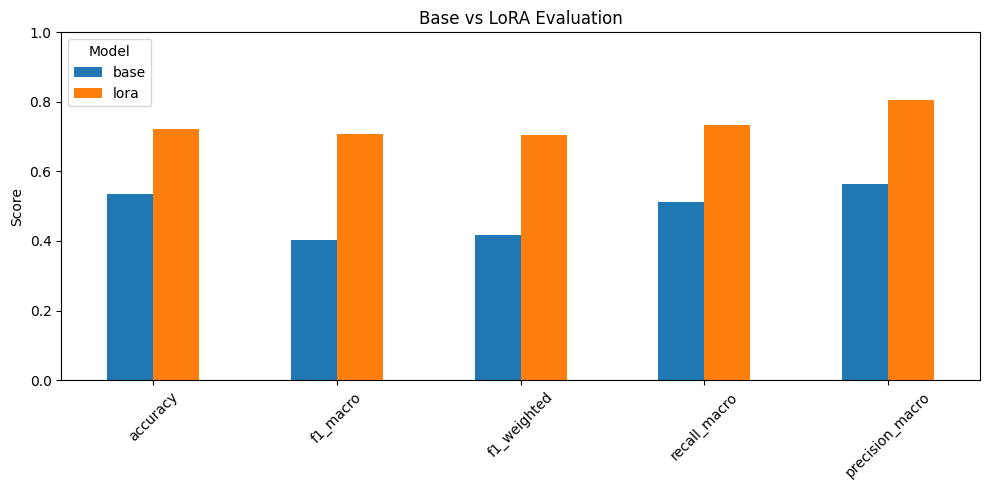

In [8]:
# Cell 8: 可视化对比
metrics_to_plot = ["accuracy", "f1_macro", "f1_weighted", "recall_macro", "precision_macro"]

plot_df = result_df.set_index("model")[metrics_to_plot]

ax = plot_df.T.plot(kind="bar", figsize=(10, 5))
ax.set_title("Base vs LoRA Evaluation")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
plt.xticks(rotation=45)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

In [9]:
# Cell 9: 分析 LoRA 相比 Base 改正了多少样本
base_correct = (df["base_pred"] == df["gold"])
lora_correct = (df["lora_pred"] == df["gold"])

df["base_correct"] = base_correct
df["lora_correct"] = lora_correct

improved = df[(df["base_correct"] == False) & (df["lora_correct"] == True)]
worsened = df[(df["base_correct"] == True) & (df["lora_correct"] == False)]
same_correct = df[(df["base_correct"] == True) & (df["lora_correct"] == True)]
same_wrong = df[(df["base_correct"] == False) & (df["lora_correct"] == False)]

print("两者都对:", len(same_correct))
print("两者都错:", len(same_wrong))
print("LoRA 修正了 Base 的错误:", len(improved))
print("LoRA 比 Base 变差的样本:", len(worsened))

display(improved.head(20))

两者都对: 1068
两者都错: 102
LoRA 修正了 Base 的错误: 1647
LoRA 比 Base 变差的样本: 944


,task,route_id,paper_id,gold,base_pred,lora_pred,changed,base_correct,lora_correct
0,success,11,59.0,success,failed,success,True,False,True
1,success,12,59.0,success,failed,success,True,False,True
2,success,13,59.0,success,failed,success,True,False,True
3,success,14,59.0,success,failed,success,True,False,True
4,success,15,59.0,success,failed,success,True,False,True
11,success,57,100.0,success,failed,success,True,False,True
19,success,141,150.0,success,failed,success,True,False,True
21,success,251,169.0,success,failed,success,True,False,True
22,success,252,169.0,success,failed,success,True,False,True
24,success,254,169.0,success,failed,success,True,False,True


In [12]:
# Cell 10: 显著性检验（McNemar test）
# 用于判断 LoRA 的提升是否具有统计显著性

try:
    from statsmodels.stats.contingency_tables import mcnemar

    # 列联表:
    #                lora_correct   lora_wrong
    # base_correct       a             b
    # base_wrong         c             d
    a = int(((base_correct == True)  & (lora_correct == True)).sum())
    b = int(((base_correct == True)  & (lora_correct == False)).sum())
    c = int(((base_correct == False) & (lora_correct == True)).sum())
    d = int(((base_correct == False) & (lora_correct == False)).sum())

    table = [[a, b],
             [c, d]]

    result = mcnemar(table, exact=False, correction=True)

    print("McNemar contingency table:")
    print(pd.DataFrame(table,
                       index=["base_correct", "base_wrong"],
                       columns=["lora_correct", "lora_wrong"]))

    print(f"\nstatistic = {result.statistic:.6f}")
    print(f"p-value   = {result.pvalue:.6e}")

    if result.pvalue < 0.05:
        print("结论: LoRA 相比 Base 的差异具有统计显著性。")
    else:
        print("结论: LoRA 相比 Base 的差异不具有统计显著性。")

except ImportError:
    print("未安装 statsmodels，跳过 McNemar 检验。")

McNemar contingency table:
              lora_correct  lora_wrong
base_correct          1068         944
base_wrong            1647         102

statistic = 190.198379
p-value   = 2.877593e-43
结论: LoRA 相比 Base 的差异具有统计显著性。
